# Pré-processamento — Câncer Cervical

**Dataset:** [Cervical Cancer (Risk Factors)](https://archive.ics.uci.edu/dataset/383/cervical+cancer+risk+factors) — UCI Machine Learning Repository

**Variável-alvo:** `Biopsy` (0 = biópsia negativa, 1 = biópsia positiva)

**Objetivo desta etapa:** transformar os dados brutos em um conjunto pronto para
modelagem, aplicando as decisões que fazem sentido a partir do que foi observado na
etapa de EDA (`01_eda.ipynb`). Esta é **apenas a etapa de pré-processamento**.
Seleção de modelos, treinamento, ajuste de hiperparâmetros, avaliação de performance
e balanceamento de classes (ex.: SMOTE) ficarão para notebooks futuros.

### Principais achados da EDA que orientam as decisões abaixo

1. **Valores ausentes:** `STDs: Time since first diagnosis` e `STDs: Time since last
   diagnosis` têm mais de 90% de dados faltantes; as demais colunas com nulos variam
   entre ~1% e ~14%.
2. **Classes desbalanceadas:** poucos casos positivos em `Biopsy` frente ao total
   (~6,4% de positivos).
3. **Risco de *data leakage*:** `Hinselmann`, `Schiller`, `Citology` e os campos
   `Dx*` são fortemente correlacionados com `Biopsy` por investigarem a mesma
   condição clínica.
4. **Fatores de risco** (tabagismo, contraceptivos hormonais/DIU, histórico de DSTs)
   têm alguma associação com o target, mas nenhum isoladamente forte.
5. **Distribuições assimétricas** com outliers em variáveis como número de parceiros
   sexuais e número de gestações.

Este notebook foi desenvolvido para rodar no **Google Colab**, usando principalmente
`pandas`, `numpy` e `scikit-learn`. `matplotlib`/`seaborn` aparecem apenas para
validar visualmente o efeito da transformação de assimetria.


## 0. Configuração do ambiente

In [1]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import joblib

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

pd.set_option("display.max_columns", None)


### Carregamento do arquivo

Mesma lógica de carregamento usada na EDA: valores `"?"` são tratados como ausentes
já na leitura, e há um fallback de upload manual caso o notebook esteja rodando no
Google Colab sem o repositório clonado localmente.

In [2]:
CSV_PATH = "../data/raw/kag_risk_factors_cervical_cancer.csv"

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB and not os.path.exists(CSV_PATH):
    from google.colab import files
    print("Arquivo não encontrado localmente. Faça o upload do CSV do dataset:")
    uploaded = files.upload()
    CSV_PATH = list(uploaded.keys())[0]

print(f"Carregando dados de: {CSV_PATH}")


Carregando dados de: ../data/raw/kag_risk_factors_cervical_cancer.csv


## 1. Carregamento e Preparação Inicial

Repetimos aqui os mesmos passos de leitura e correção de tipos feitos na EDA, para
que este notebook seja independente e possa ser executado sozinho.

In [3]:
df = pd.read_csv(CSV_PATH, na_values="?")

# Colunas numéricas foram lidas como "object" por causa do "?" no meio dos dados.
# Convertendo para numérico agora que os "?" já viraram NaN.
colunas_objeto = df.select_dtypes(include="object").columns.tolist()
for coluna in colunas_objeto:
    df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

print(f"Shape inicial: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()


Shape inicial: 858 linhas x 36 colunas


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs,STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0


## 2. Tratamento de Valores Ausentes

### 2.1 Colunas com mais de 90% de dados faltantes

A EDA identificou que `STDs: Time since first diagnosis` e `STDs: Time since last
diagnosis` têm mais de 90% de valores ausentes.

**Decisão: remover essas duas colunas.**

**Por quê:** com menos de 10% de linhas preenchidas, qualquer estratégia de
imputação (média, mediana, etc.) estaria basicamente "inventando" a informação para
mais de 9 em cada 10 pacientes. Isso adicionaria ruído ao invés de sinal útil, e o
risco de distorcer o aprendizado do modelo é maior do que o benefício de manter a
coluna. Como o dataset já possui `STDs (number)` e `STDs: Number of diagnosis`, que
capturam a mesma ideia (histórico de DSTs) de forma muito mais completa, a perda de
informação ao remover essas duas colunas é pequena.

In [4]:
colunas_muito_esparsas = [
    "STDs: Time since first diagnosis",
    "STDs: Time since last diagnosis",
]

df = df.drop(columns=colunas_muito_esparsas)
print(f"Shape após remover colunas muito esparsas: {df.shape[0]} linhas x {df.shape[1]} colunas")


Shape após remover colunas muito esparsas: 858 linhas x 34 colunas


### 2.2 Estratégia para as demais colunas com nulos

As colunas restantes têm entre ~1% e ~14% de valores ausentes — uma proporção baixa o
suficiente para que a imputação seja uma escolha razoável (ao invés de descartar
linhas ou colunas inteiras).

**Decisão:**
- **Variáveis numéricas** (contagens, idades, anos de uso): imputar pela **mediana**.
  A mediana é mais robusta que a média para essas variáveis, já que a EDA mostrou
  distribuições assimétricas (cauda longa à direita) em várias delas — a média seria
  puxada para cima por poucos valores extremos.
- **Variáveis binárias/categóricas** (indicadores 0/1, como `Smokes`, `IUD`, cada
  `STDs:*`): imputar pela **moda** (valor mais frequente). Como a EDA mostrou que a
  grande maioria dessas variáveis tem prevalência baixa (a maioria das pacientes é 0),
  a moda quase sempre será 0 — o que é a suposição mais razoável na ausência de
  informação.

**Importante:** para não vazar informação do conjunto de teste para o treino, a
imputação só será **ajustada (fit)** nos dados de treino. Por isso a aplicação prática
dessa estratégia aparece mais adiante (Seção 5), depois da separação treino/teste. Aqui
deixamos a decisão registrada; a execução vem em seguida, na ordem correta.

## 3. Tratamento do Risco de Data Leakage

A EDA mostrou que `Hinselmann`, `Schiller`, `Citology` (outros exames de rastreio) e
os campos `Dx`, `Dx:Cancer`, `Dx:CIN`, `Dx:HPV` (diagnósticos) são as variáveis mais
fortemente correlacionadas com `Biopsy`. Isso não é uma coincidência estatística: são
formas diferentes de investigar ou registrar a mesma condição clínica (lesão
cervical/câncer).

**Decisão: remover essas 7 colunas do conjunto de variáveis preditoras (`X`).**

**Por quê:** em um cenário real de uso do modelo, essas informações normalmente **não
estariam disponíveis antes da biópsia** — ou seriam, na prática, um substituto quase
direto da resposta que queremos prever. Usá-las como preditoras faria o modelo parecer
artificialmente muito bom nos dados históricos (porque está "espiando" resultados de
exames relacionados), mas performar mal em um cenário real de triagem de risco, que é
o objetivo do projeto. Por isso elas são excluídas do conjunto preditor, embora
continuem preservadas no dataset original para eventual consulta futura.

In [5]:
colunas_vazamento = ["Hinselmann", "Schiller", "Citology", "Dx", "Dx:Cancer", "Dx:CIN", "Dx:HPV"]

print("Colunas excluídas do conjunto preditor por risco de vazamento de dados:")
print(colunas_vazamento)


Colunas excluídas do conjunto preditor por risco de vazamento de dados:
['Hinselmann', 'Schiller', 'Citology', 'Dx', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV']


## 4. Definição das Variáveis Preditoras (X) e do Alvo (y)

Juntando as decisões acima: `y` é a variável `Biopsy`; `X` é o restante das colunas,
exceto as removidas por excesso de nulos e as removidas por risco de vazamento.

In [6]:
TARGET = "Biopsy"

y = df[TARGET].copy()
X = df.drop(columns=[TARGET] + colunas_vazamento).copy()

print(f"X: {X.shape[0]} linhas x {X.shape[1]} colunas")
print(f"y: {y.shape[0]} valores")
X.columns.tolist()


X: 858 linhas x 26 colunas
y: 858 valores


['Age',
 'Number of sexual partners',
 'First sexual intercourse',
 'Num of pregnancies',
 'Smokes',
 'Smokes (years)',
 'Smokes (packs/year)',
 'Hormonal Contraceptives',
 'Hormonal Contraceptives (years)',
 'IUD',
 'IUD (years)',
 'STDs',
 'STDs (number)',
 'STDs:condylomatosis',
 'STDs:cervical condylomatosis',
 'STDs:vaginal condylomatosis',
 'STDs:vulvo-perineal condylomatosis',
 'STDs:syphilis',
 'STDs:pelvic inflammatory disease',
 'STDs:genital herpes',
 'STDs:molluscum contagiosum',
 'STDs:AIDS',
 'STDs:HIV',
 'STDs:Hepatitis B',
 'STDs:HPV',
 'STDs: Number of diagnosis']

### Classificação das colunas de X por tipo

Separar as colunas de `X` em numéricas e binárias/categóricas é necessário para
aplicar a estratégia de imputação correta em cada grupo (Seção 2.2) e para decidir
quais colunas serão padronizadas (Seção 7).

In [7]:
colunas_numericas = [
    "Age",
    "Number of sexual partners",
    "First sexual intercourse",
    "Num of pregnancies",
    "Smokes (years)",
    "Smokes (packs/year)",
    "Hormonal Contraceptives (years)",
    "IUD (years)",
    "STDs (number)",
    "STDs: Number of diagnosis",
]

colunas_binarias = [c for c in X.columns if c not in colunas_numericas]

# Confere que todas as colunas de X foram classificadas
assert set(colunas_numericas + colunas_binarias) == set(X.columns)
print("Variáveis numéricas em X:", len(colunas_numericas))
print("Variáveis binárias/categóricas em X:", len(colunas_binarias))


Variáveis numéricas em X: 10
Variáveis binárias/categóricas em X: 16


## 5. Separação Treino/Teste (Split Estratificado)

Como `Biopsy` é uma classe rara (~6,4% de positivos), um split aleatório comum
poderia, por azar, concentrar quase todos os poucos casos positivos em um dos dois
conjuntos. Por isso usamos `stratify=y`, que garante que treino e teste mantenham
aproximadamente a mesma proporção de positivos e negativos observada no dataset
completo.

O split é feito **agora, antes da imputação e da padronização**, exatamente para que
essas próximas etapas possam ser ajustadas (`fit`) somente nos dados de treino — se
fizéssemos isso antes do split, estatísticas do conjunto de teste (como a mediana ou o
desvio padrão) vazariam para o treino, o que é uma forma sutil, mas real, de *data
leakage*.

**Nota importante:** nenhuma técnica de balanceamento de classes (ex.: SMOTE) é
aplicada neste notebook. Isso é proposital: balanceamento deve ser aplicado **somente
sobre o conjunto de treino**, e apenas na etapa de modelagem — nunca antes do split,
e nunca no conjunto de teste, para não inflar artificialmente a performance avaliada
depois.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train = X_train.copy()
X_test = X_test.copy()

print(f"Treino: {X_train.shape[0]} linhas ({y_train.mean() * 100:.2f}% positivos)")
print(f"Teste:  {X_test.shape[0]} linhas ({y_test.mean() * 100:.2f}% positivos)")


Treino: 686 linhas (6.41% positivos)
Teste:  172 linhas (6.40% positivos)


## 6. Aplicação da Imputação de Valores Ausentes

Agora aplicamos, na prática, a estratégia definida na Seção 2.2: mediana para
variáveis numéricas e moda para variáveis binárias/categóricas. Os imputadores são
ajustados (`fit`) **apenas no treino** e depois usados para transformar tanto o
treino quanto o teste — assim o teste é tratado exatamente como dados novos, nunca
vistos antes.

In [9]:
imputer_numerico = SimpleImputer(strategy="median")
imputer_binario = SimpleImputer(strategy="most_frequent")

X_train[colunas_numericas] = imputer_numerico.fit_transform(X_train[colunas_numericas])
X_test[colunas_numericas] = imputer_numerico.transform(X_test[colunas_numericas])

X_train[colunas_binarias] = imputer_binario.fit_transform(X_train[colunas_binarias])
X_test[colunas_binarias] = imputer_binario.transform(X_test[colunas_binarias])

print("Valores nulos restantes no treino:", X_train.isnull().sum().sum())
print("Valores nulos restantes no teste:", X_test.isnull().sum().sum())


Valores nulos restantes no treino: 0
Valores nulos restantes no teste: 0


## 7. Tratamento de Distribuições Assimétricas

A EDA mostrou que `Number of sexual partners` e `Num of pregnancies` têm distribuição
concentrada em valores baixos, com uma cauda longa de poucos pacientes com valores
bem mais altos (outliers "naturais", não erros de digitação).

**Decisão: aplicar transformação logarítmica (`log1p`), em vez de winsorização.**

**Por quê:**
- `log1p(x) = log(1 + x)` comprime a cauda longa sem descartar nenhuma observação —
  ao contrário da winsorização, que "corta" os valores extremos em um teto arbitrário,
  perdendo informação sobre quem de fato tem valores muito altos.
- Funciona bem para variáveis de contagem como estas (sempre ≥ 0, com muitos zeros ou
  valores baixos e poucos valores altos).
- É uma transformação simples, determinística e sem parâmetros a serem "aprendidos"
  dos dados — ou seja, pode ser aplicada da mesma forma em treino e teste sem risco de
  vazamento de informação.

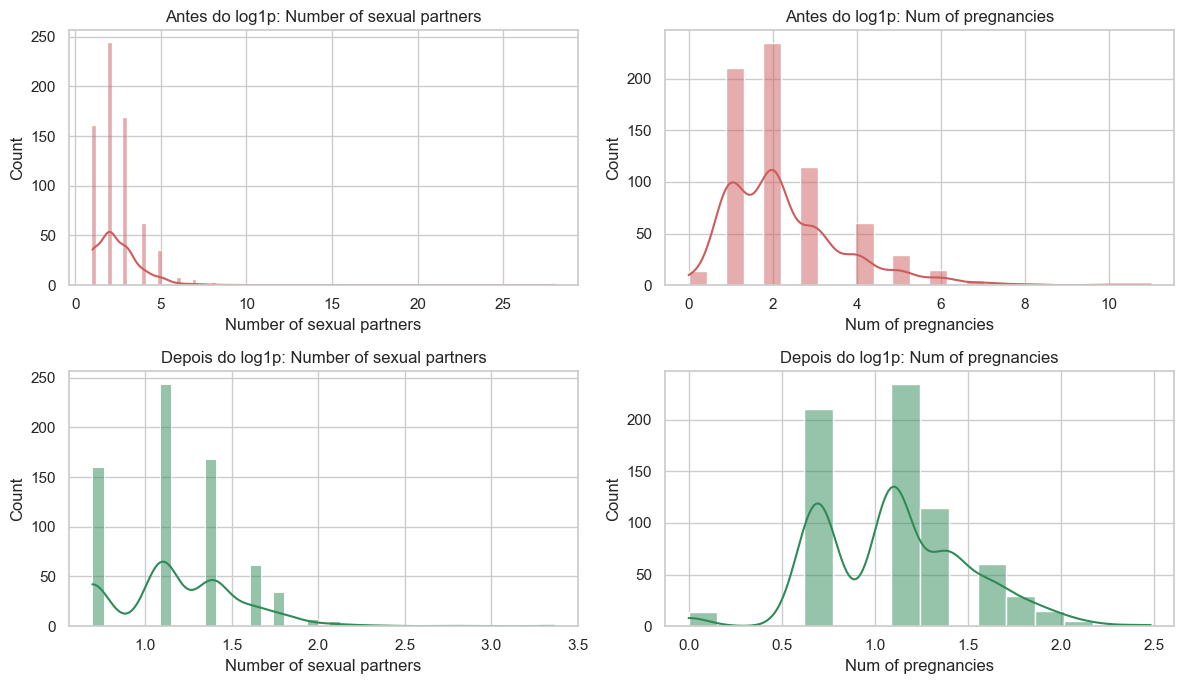

In [10]:
colunas_assimetricas = ["Number of sexual partners", "Num of pregnancies"]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

for i, coluna in enumerate(colunas_assimetricas):
    sns.histplot(X_train[coluna], kde=True, ax=axes[0, i], color="indianred")
    axes[0, i].set_title(f"Antes do log1p: {coluna}")

    transformado = np.log1p(X_train[coluna])
    sns.histplot(transformado, kde=True, ax=axes[1, i], color="seagreen")
    axes[1, i].set_title(f"Depois do log1p: {coluna}")

plt.tight_layout()
plt.show()


**Interpretação:** após o `log1p`, as distribuições ficam visivelmente menos concentradas em valores baixos e menos puxadas pela cauda longa — mais próximas de uma distribuição simétrica, o que costuma ajudar modelos sensíveis à escala e à forma da distribuição (ex.: regressão logística).

In [11]:
for coluna in colunas_assimetricas:
    X_train[coluna] = np.log1p(X_train[coluna])
    X_test[coluna] = np.log1p(X_test[coluna])

print("Transformação log1p aplicada em:", colunas_assimetricas)


Transformação log1p aplicada em: ['Number of sexual partners', 'Num of pregnancies']


## 8. Codificação e Padronização

### Codificação de variáveis categóricas

Verificamos os tipos de dados finais de `X`: todas as colunas do dataset já são
numéricas por natureza (contagens, anos, indicadores 0/1) — não existe nenhuma coluna
de texto/categoria livre que exigiria codificação (ex.: one-hot encoding). Por isso,
nenhuma etapa adicional de codificação é necessária aqui.

In [12]:
X_train.dtypes.value_counts()


float64    26
Name: count, dtype: int64

### Padronização das variáveis numéricas

Aplicamos `StandardScaler` (média 0, desvio padrão 1) apenas nas variáveis numéricas
contínuas/discretas (`colunas_numericas`). As variáveis binárias (0/1) **não** são
padronizadas — elas já estão em uma escala fixa e comparável, e padronizá-las
dificultaria a interpretação sem trazer benefício real.

Assim como na imputação, o `scaler` é ajustado (`fit`) apenas no treino e depois
aplicado ao teste, para evitar que estatísticas do teste (média, desvio padrão)
influenciem o treino.

In [13]:
scaler = StandardScaler()

X_train[colunas_numericas] = scaler.fit_transform(X_train[colunas_numericas])
X_test[colunas_numericas] = scaler.transform(X_test[colunas_numericas])

X_train[colunas_numericas].describe().T[["mean", "std"]]


,mean,std
Age,1.139354e-16,1.00073
Number of sexual partners,-3.884162e-17,1.00073
First sexual intercourse,1.916187e-16,1.00073
Num of pregnancies,-5.826243e-17,1.00073
Smokes (years),-2.589441e-17,1.00073
Smokes (packs/year),5.178883e-18,1.00073
Hormonal Contraceptives (years),5.178883e-18,1.00073
IUD (years),-3.107330e-17,1.00073
STDs (number),5.696771e-17,1.00073
STDs: Number of diagnosis,6.214659e-17,1.00073


## 9. Exportação dos Dados Processados

Exportamos os conjuntos de treino e teste **já prontos para modelagem**, cada um em
um arquivo CSV separado, contendo as variáveis preditoras (`X`) processadas mais a
coluna `Biopsy` (`y`):

- **`data/processed/cervical_cancer_train_processed.csv`**: conjunto de treino
  (imputado, com `log1p` aplicado e padronizado), a ser usado para treinar modelos e,
  se necessário, aplicar balanceamento de classes (SMOTE ou similar) na etapa
  seguinte.
- **`data/processed/cervical_cancer_test_processed.csv`**: conjunto de teste,
  transformado com os mesmos parâmetros aprendidos no treino (nunca re-ajustados),
  para ser usado exclusivamente na avaliação final dos modelos.

Também salvamos os transformadores ajustados (`imputer_numerico`, `imputer_binario`,
`scaler`) e a lista de colunas usadas em cada etapa em `/models/`, para que a etapa de
modelagem (ou uma futura aplicação em dados novos) possa reaplicar exatamente as
mesmas transformações, sem precisar reajustá-las.

In [14]:
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../models", exist_ok=True)

train_df = X_train.copy()
train_df[TARGET] = y_train.values

test_df = X_test.copy()
test_df[TARGET] = y_test.values

train_path = "../data/processed/cervical_cancer_train_processed.csv"
test_path = "../data/processed/cervical_cancer_test_processed.csv"

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

print(f"Treino salvo em '{train_path}': {train_df.shape[0]} linhas x {train_df.shape[1]} colunas")
print(f"Teste salvo em '{test_path}': {test_df.shape[0]} linhas x {test_df.shape[1]} colunas")


Treino salvo em '../data/processed/cervical_cancer_train_processed.csv': 686 linhas x 27 colunas
Teste salvo em '../data/processed/cervical_cancer_test_processed.csv': 172 linhas x 27 colunas


In [15]:
joblib.dump(imputer_numerico, "../models/imputer_numerico.joblib")
joblib.dump(imputer_binario, "../models/imputer_binario.joblib")
joblib.dump(scaler, "../models/scaler_numerico.joblib")

metadados_preprocessamento = {
    "target": TARGET,
    "colunas_numericas": colunas_numericas,
    "colunas_binarias": colunas_binarias,
    "colunas_assimetricas_log1p": colunas_assimetricas,
    "colunas_removidas_por_nulos": colunas_muito_esparsas,
    "colunas_removidas_por_vazamento": colunas_vazamento,
}

with open("../models/preprocessing_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadados_preprocessamento, f, ensure_ascii=False, indent=2)

print("Transformadores e metadados salvos em /models/")


Transformadores e metadados salvos em /models/


## 10. Síntese da Etapa de Pré-processamento

Resumo das decisões tomadas neste notebook, todas conectadas aos achados da EDA:

1. **Valores ausentes:** as duas colunas com mais de 90% de nulos
   (`STDs: Time since first/last diagnosis`) foram removidas. As demais colunas com
   nulos (1% a 14%) foram imputadas — mediana para numéricas, moda para
   binárias/categóricas — sempre ajustando a imputação apenas no conjunto de treino.
2. **Data leakage:** `Hinselmann`, `Schiller`, `Citology`, `Dx`, `Dx:Cancer`,
   `Dx:CIN` e `Dx:HPV` foram removidas do conjunto de variáveis preditoras, por
   investigarem a mesma condição clínica que estamos tentando prever.
3. **Assimetria:** `Number of sexual partners` e `Num of pregnancies` passaram por
   transformação `log1p`, que reduz a cauda longa dessas distribuições sem descartar
   observações.
4. **Codificação/padronização:** não há variáveis categóricas de texto a codificar;
   as variáveis numéricas contínuas foram padronizadas (`StandardScaler`), e as
   binárias foram mantidas como estão.
5. **Split treino/teste:** feito de forma estratificada (`stratify=y`) para preservar
   a proporção de casos positivos, e **antes** de qualquer imputação/padronização,
   para evitar vazamento de informação do teste para o treino.
6. **Balanceamento de classes:** **não foi aplicado neste notebook.** Técnicas como
   SMOTE devem ser usadas apenas na etapa de modelagem, e apenas sobre o conjunto de
   treino já separado — nunca antes do split.

**Próximos passos (fora do escopo deste notebook):** seleção de modelos, eventual
balanceamento de classes no treino, treinamento, ajuste de hiperparâmetros e avaliação
de performance.